**개념 설명**

## 7.1 시계열 문제

시계열 분석: 시간에 따라 변하는 데이터를 사용하여 추이를 분석하는 것
- 시계열 형태: 불규칙 변동, 추세 변동, 순환 변동, 계절 변동
    - 불규칙 변동: 시간에 따른 규칙적인 움직임과 달리 어떤 규칙성이 없어 예측 불가능하고 우연적으로 발생
    - 추세 변동: 장기적인 변화 추세
    - 순환 변동: 대체로 2~3년 정도의 일정한 기간을 주기로 순환적으로 나타남
    - 계절 변동: 계절적 영향과 관습에 따라 1년 주기로 발생
- 규칙적 시계열 vs 불규칙적 시계열
    - 규칙적 시계열: 트렌드와 분산이 불변하는 데이터
    - 불규칙적 시계열: 트렌드 혹은 분산이 변화하는 데이터
        - 규칙성 부여: AR, MA, ARMA, ARIMA

## 7.2 AR, MA, ARMA, ARIMA

### 7.2.1 AR 모델

AR: 이전 관측 값이 이후 관측 값에 영향을 준다는 아이디어에 대한 모형

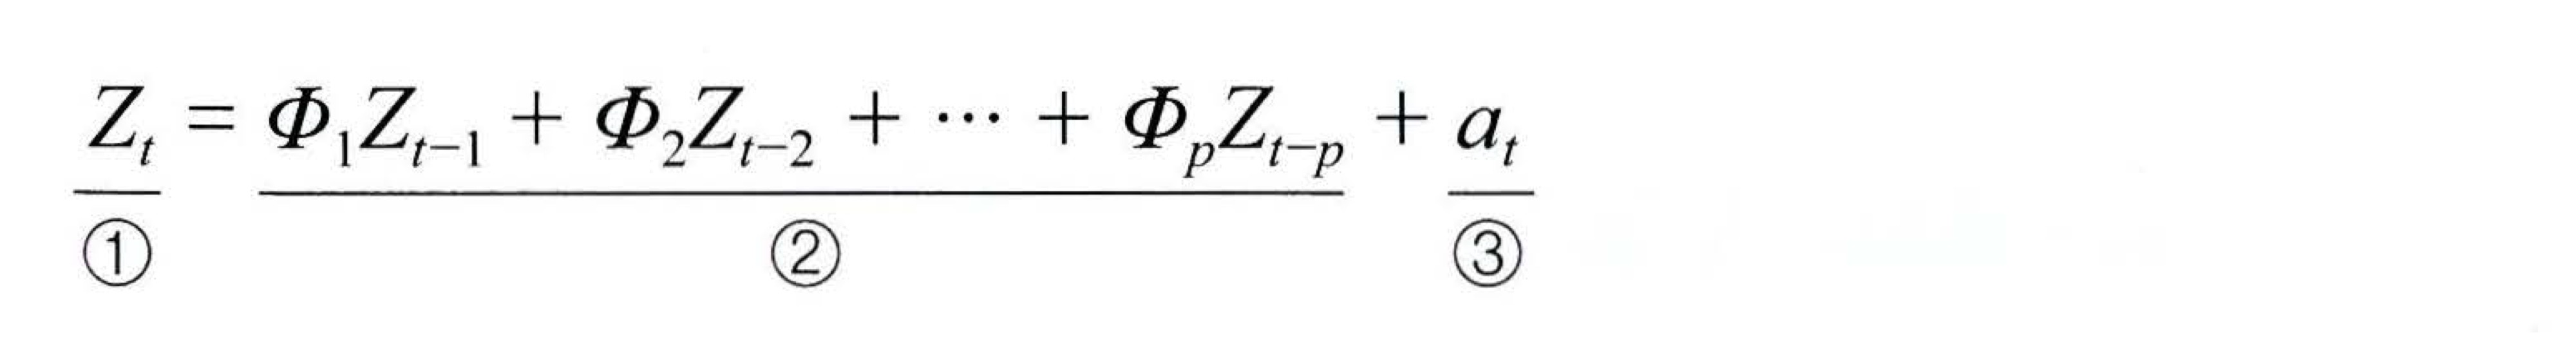

1) 현재 시점
2) 과거가 현재에 미치는 영향을 나타내는 모수에 시계열 데이터의 과거 시점을 곱한 것
3) 오차 항 (=백색 잡음)

### 7.2.2 MA 모델

MA: 트렌드가 변화하는 상황에 적합
- 시계열을 따라 윈도우 크기만큼 슬라이딩

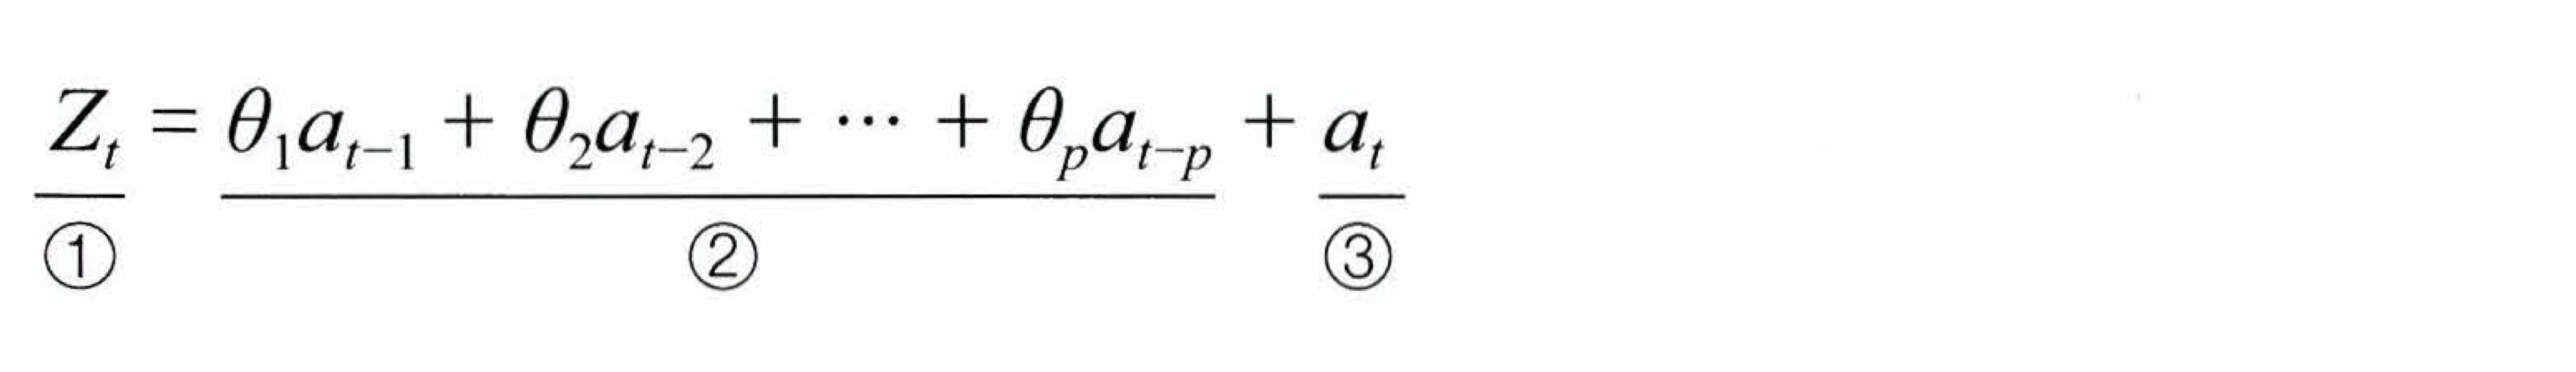

1) 현재 시점
2) 매개변수에 과거 시점의 오차를 곱한 것
3) 오차 항

### 7.2.3 ARMA 모델

ARMA: AR과 MA를 섞은 모델, 연구 기관에서 주로 사용

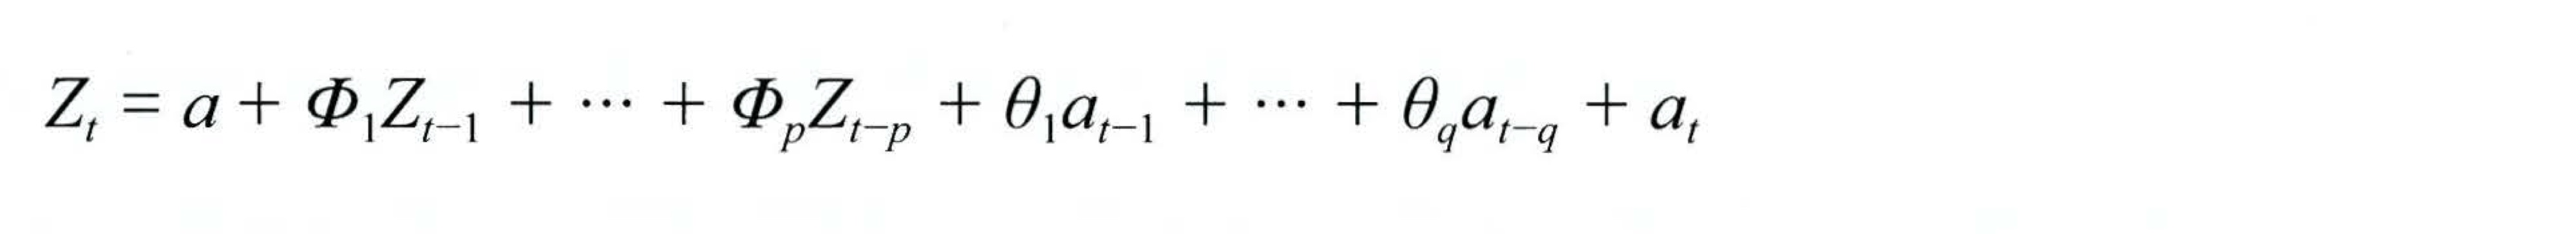

### 7.2.4 ARIMA 모델

ARIMA: 자기 회귀와 이동평균을 둘 다 고려, 과거 데이터의 선형 관계 뿐만 아니라 추세까지
- ARIMA(p,d,q) 함수 호출
    - p: 자기 회귀 차수 / d: 차분 차수 / q: 이동 평균 차수

- statsmodels 라이브러리
    - 검정 및 추정, 회귀 분석, 시계열 분석

## 7.3 순환 신경망(RNN)

RNN: 시간적으로 연속성이 있는 데이터를 처리하려고 고안된 인공 신경망
- 이전 은닉층이 현재 은닉층의 입력이 되면서 반복되는 순환 구조를 가짐
- 기존 네트워크와 다른 점: 기억을 가짐, 현재까지 입력 데이터를 요약한 정보
- 입력과 출력에 따른 유형
    - 일대일: 순환이 없기 때문에 RNN이라고 말하기 어려움
    - 일대다: 입력이 하나, 출력이 다수
    - 다대일: 입력이 다수, 출력이 하나
    - 다대다: 입력과 출력이 다수
    - 동기화 다대다: 입력과 출력이 다수

### 7.3.1 RNN 계층과 셀

RNN은 내장된 계층 뿐만 아니라 셀 레벨의 API도 제공
- RNN 계층: 입력된 배치 순서대로 모두 처리
    - 셀을 래핑하여 동일한 셀을 여러 단계에 적용
- RNN 셀: 오직 하나의 단계만 처리
    - nn.RNNCell, nn.GRUCell, nn.LSTMCell

**코드 필사**

In [1]:
!pip install statsmodels

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a 

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -199.651
Date:                Tue, 25 Nov 2025   AIC                            411.302
Time:                        16:52:11   BIC                            420.634
Sample:                             0   HQIC                           414.523
                                 - 36                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8788      0.227     -3.876      0.000      -1.323      -0.434
ar.L2         -0.2787      0.232     -1.203      0.229      -0.733       0.176
ar.L3         -0.0076      0.270     -0.028      0.9

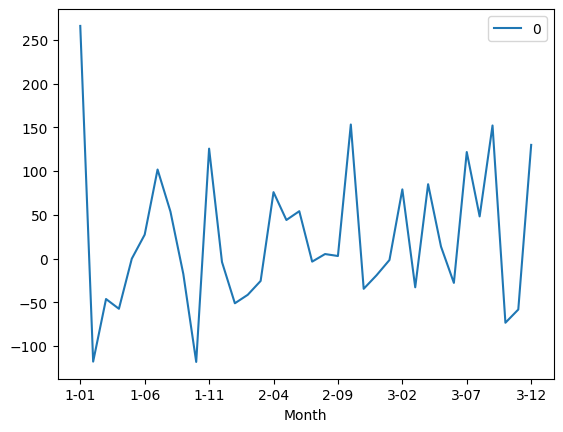

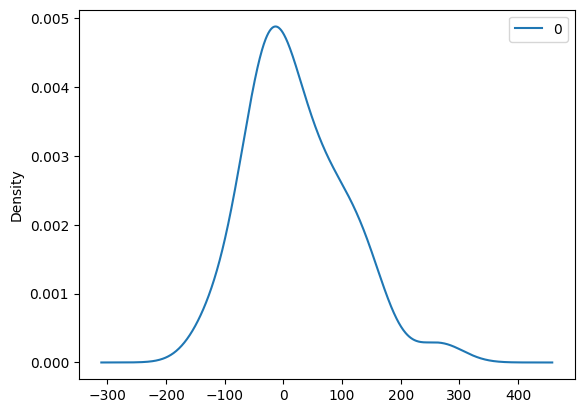

                0
count   36.000000
mean    22.459086
std     82.505331
min   -118.213281
25%    -33.308343
50%      1.361178
75%     76.704967
max    266.000000


In [5]:
#ARIMA() 함수를 호출하여 sales 데이터셋에 대한 예측
from pandas import read_csv
from datetime import datetime
from pandas import DataFrame
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot

def parser(x):
    return datetime.strptime('199'+x, '%Y-%m')

series=read_csv('sales.csv', header=0, parse_dates=[0], index_col=0, date_format=parser)
model=ARIMA(series, order=(5,1,0))
model_fit=model.fit()
print(model_fit.summary())
residuals=DataFrame(model_fit.resid)
residuals.plot()
pyplot.show()
residuals.plot(kind='kde')
pyplot.show()
print(residuals.describe())

/tmp/ipython-input-1239335889.py:12: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  series=read_csv('sales.csv', header=0, parse_dates=[0], index_col=0, date_parser=parser)
/tmp/ipython-input-1239335889.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('predicted=%f, expected=%f' % (yhat, obs))


predicted=352.855343, expected=346.300000
predicted=277.398036, expected=329.700000
predicted=368.753734, expected=445.400000
predicted=331.773635, expected=325.900000
predicted=372.070407, expected=449.300000
predicted=360.020872, expected=411.300000
predicted=454.526230, expected=417.400000
predicted=388.690699, expected=545.500000
predicted=437.632447, expected=477.600000
predicted=516.437624, expected=687.000000
predicted=520.916191, expected=435.300000
predicted=675.594647, expected=587.300000
predicted=505.201016, expected=676.900000
Test MSE: 9118.818


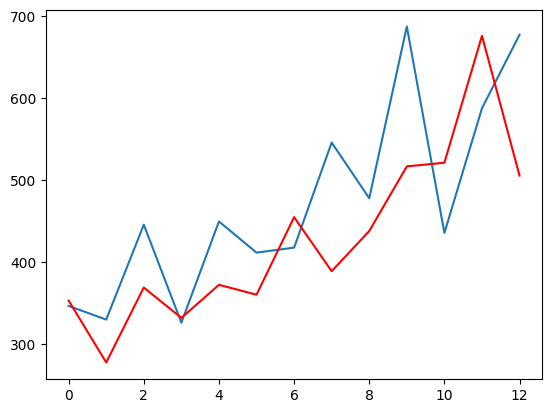

In [6]:
#statsmodels 라이브러리를 이용한 sales 데이터셋 예측
import numpy as np
from pandas import read_csv
from datetime import datetime
from matplotlib import pyplot
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

def parser(x):
    return datetime.strptime('199'+x, '%Y-%m')

series=read_csv('sales.csv', header=0, parse_dates=[0], index_col=0, date_parser=parser)

X=series.values
X=np.nan_to_num(X)
size=int(len(X) * 0.66)
train, test=X[0:size], X[size:len(X)]
history=[x for x in train]
predictions=list()
for t in range(len(test)):
    model=ARIMA(history, order=(5,1,0))
    model_fit=model.fit()
    output=model_fit.forecast()
    yhat=output[0]
    predictions.append(yhat)
    obs=test[t]
    history.append(obs)
    print('predicted=%f, expected=%f' % (yhat, obs))
error=mean_squared_error(test, predictions)
print('Test MSE: %.3f' % error)
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()